In [1]:
import pandas as pd

In [2]:
# ==============================
# Core Python Libraries
# ==============================
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ==============================
# Date & Time Handling
# ==============================
from datetime import datetime, timedelta

# ==============================
# Scikit-Learn (ML Core)
# ==============================
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    silhouette_score
)
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# ==============================
# Time Series Modeling
# ====================


In [3]:
df = pd.read_csv("./AEP_hourly.csv")

In [4]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121273 entries, 0 to 121272
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  121273 non-null  object 
 1   AEP_MW    121273 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.9+ MB


In [6]:
df.head(100)

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
...,...,...
95,2004-12-29 00:00:00,16047.0
96,2004-12-27 01:00:00,16718.0
97,2004-12-27 02:00:00,16150.0
98,2004-12-27 03:00:00,16090.0


In [7]:
df.shape

(121273, 2)

In [8]:
df.describe()

,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [9]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.set_index('Datetime')

temporal resolution:

In [10]:
df.index.inferred_freq

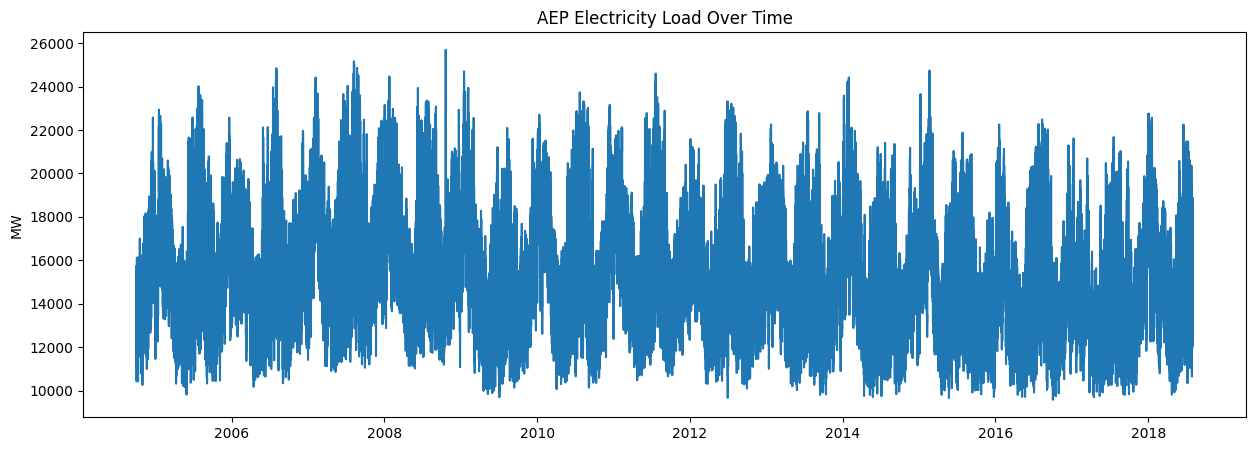

In [11]:
plt.figure(figsize=(15,5))
plt.plot(df['AEP_MW'])
plt.title("AEP Electricity Load Over Time")
plt.ylabel("MW")
plt.show()

In [12]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['year'] = df.index.year
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

In [13]:
features = ['AEP_MW', 'hour', 'dayofweek', 'month']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['regime'] = labels

In [15]:
df['regime'].value_counts(normalize=True)

regime
1    0.283278
3    0.261254
2    0.243888
0    0.211580
Name: proportion, dtype: float64

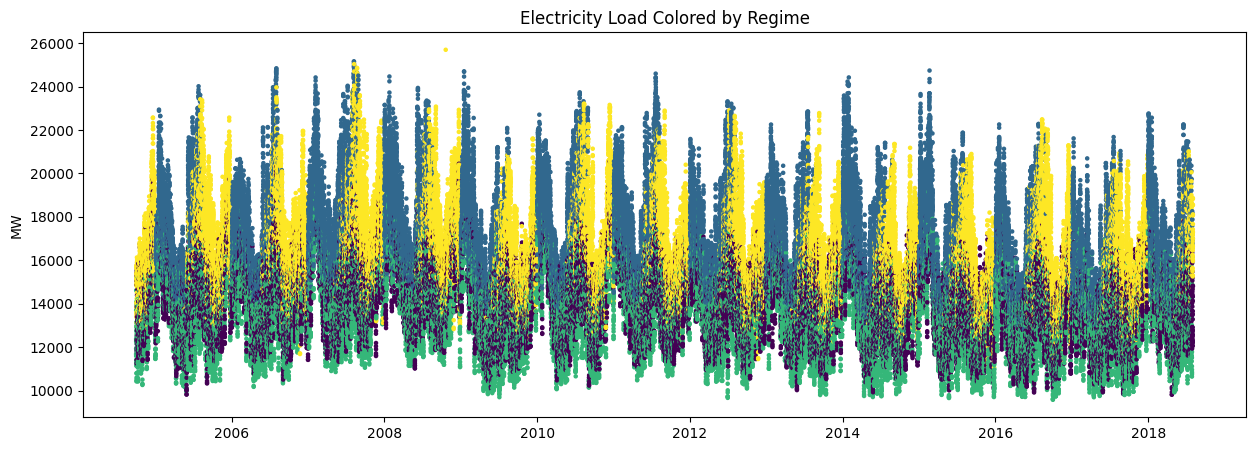

In [16]:
plt.figure(figsize=(15,5))
plt.scatter(df.index, df['AEP_MW'], c=df['regime'], cmap='viridis', s=5)
plt.title("Electricity Load Colored by Regime")
plt.ylabel("MW")
plt.show()

In [17]:
df.groupby('regime')['AEP_MW'].describe()

,count,mean,std,min,25%,50%,75%,max
regime,,,,,,,,
0,25659.0,13781.146927,1607.641557,9815.0,12509.5,13772.0,14933.0,20556.0
1,34354.0,17448.232462,2160.472184,11502.0,15793.0,17264.0,18888.0,25164.0
2,29577.0,13403.442202,1614.883016,9581.0,12231.0,13346.0,14515.0,19437.0
3,31683.0,16734.901682,1994.779175,10511.0,15287.0,16518.0,18017.0,25695.0


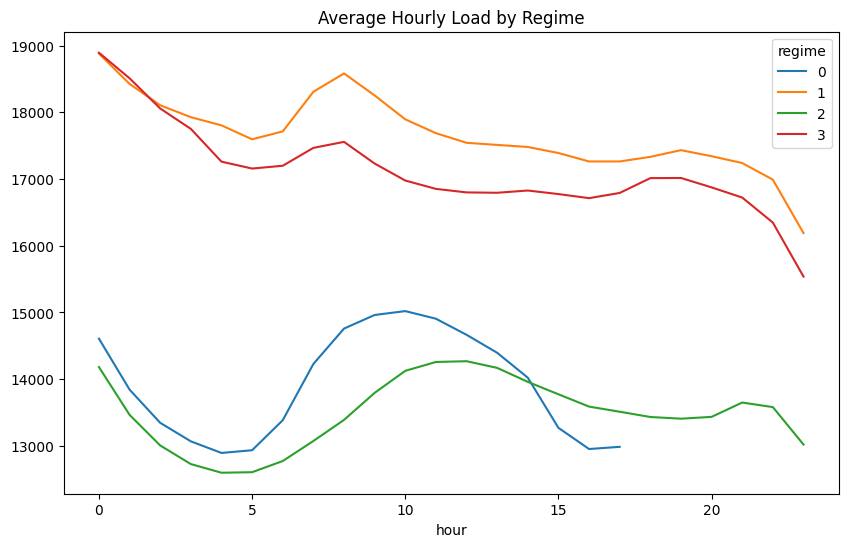

In [18]:
hour_regime = df.groupby(['hour','regime'])['AEP_MW'].mean().unstack()

hour_regime.plot(figsize=(10,6))
plt.title("Average Hourly Load by Regime")
plt.show()

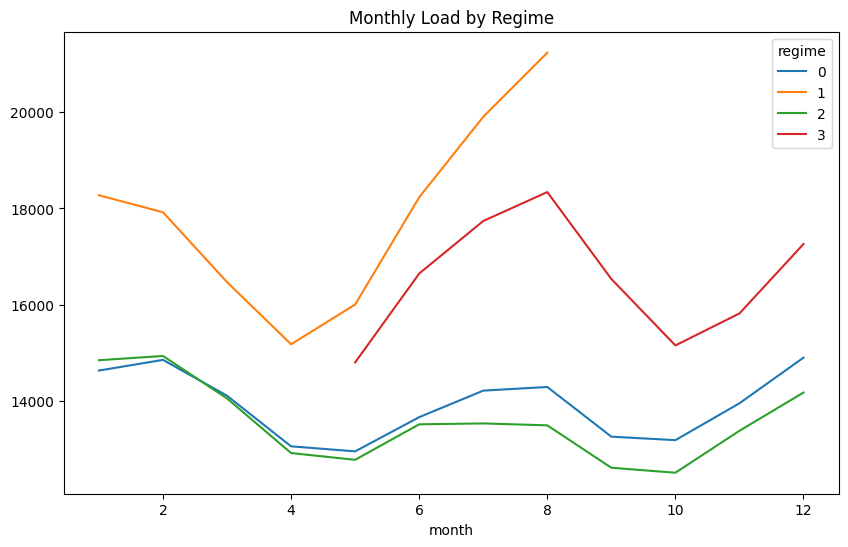

In [19]:
month_regime = df.groupby(['month','regime'])['AEP_MW'].mean().unstack()

month_regime.plot(figsize=(10,6))
plt.title("Monthly Load by Regime")
plt.show()

In [20]:
df.groupby(['is_weekend','regime'])['AEP_MW'].mean().unstack()

regime,0,1,2,3
is_weekend,,,,
0,13781.146927,17464.684896,13647.795324,16882.725823
1,NaN,17302.641628,13337.467173,16286.783306


In [ ]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(X_scaled, labels)
sil_score

In [ ]:
df['prev_regime'] = df['regime'].shift(1)

transition_matrix = pd.crosstab(df['prev_regime'], df['regime'], normalize='index')
transition_matrix

regime,0,1,2,3
prev_regime,,,,
0.0,0.881986,0.055694,0.012667,0.049653
1.0,0.033533,0.933952,0.022326,0.010188
2.0,0.006796,0.025188,0.928424,0.039592
3.0,0.052899,0.002998,0.032320,0.911782


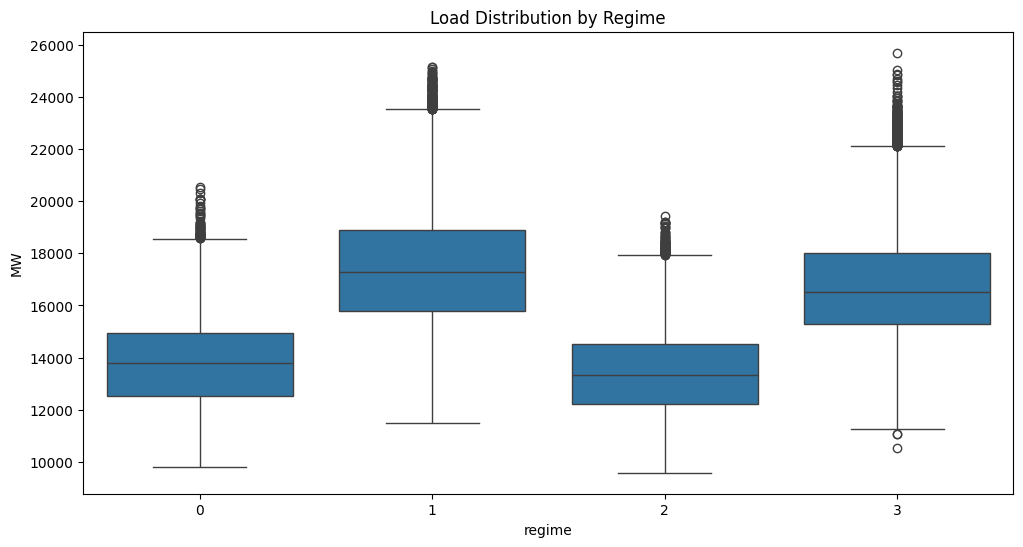

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='regime', y='AEP_MW', data=df)
plt.title("Load Distribution by Regime")
plt.ylabel("MW")
plt.show()

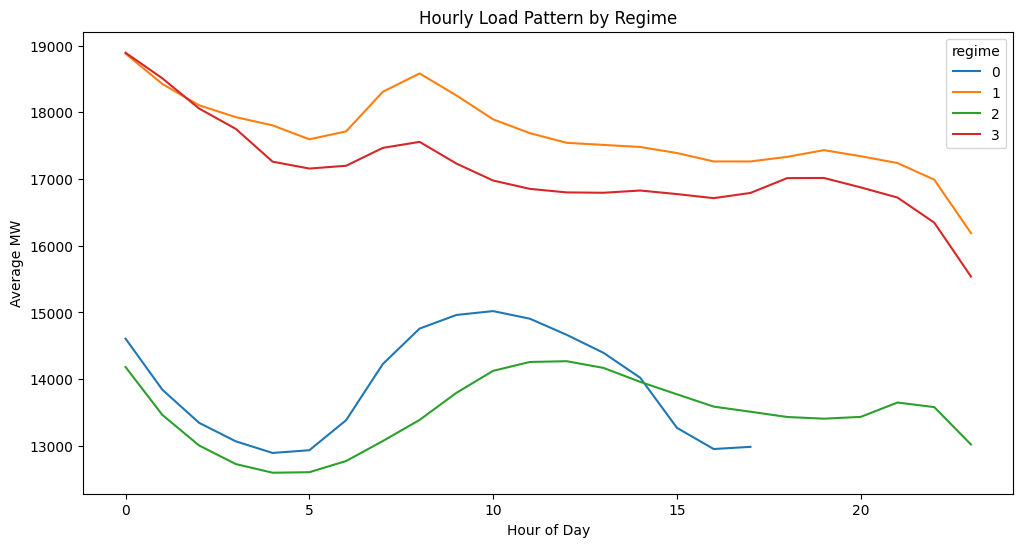

In [ ]:
hourly_pattern = df.groupby(['hour','regime'])['AEP_MW'].mean().unstack()

hourly_pattern.plot(figsize=(12,6))
plt.title("Hourly Load Pattern by Regime")
plt.ylabel("Average MW")
plt.xlabel("Hour of Day")
plt.show()

In [ ]:
weekly_pattern = df.groupby(['dayofweek','regime'])['AEP_MW'].mean().unstack()

weekly_pattern.plot(figsize=(12,6))
plt.title("Day-of-Week Load Pattern by Regime")
plt.ylabel("Average MW")
plt.xlabel("Day of Week (0=Monday)")
plt.show()

: 

In [ ]:
df_model = df.dropna()

In [ ]:
features = [
    'hour','dayofweek','month','is_weekend',
    'hour_sin','hour_cos',
    'month_sin','month_cos',
    'lag_1','lag_24','lag_168',
    'rolling_mean_24','rolling_std_24',
    'rolling_mean_168','rolling_std_168',
    'regime'
]

X = df_model[features]
y = df_model['AEP_MW']